# NB10 - Attention U-Net Final Model (ONE architecture experiment)

M1 inputs ONLY (VV/VH/DEM, 3ch): locked M1 U-Net vs Attention U-Net (same encoder/decoder + attention gates on skips). ONLY intended change = architecture. NB06-M1 protocol (seed 42, batch 4, AdamW 1e-3/1e-4, 40 ep, plateau f=0.5/p=4, patience 8 on val IoU, masked 0.5BCE+0.5Dice, AMP, thr 0.5). M1 NOT retrained. Pre-registered rule: Attention U-Net becomes FINAL iff test IoU >= M1+0.005 AND Bolivia IoU >= M1-0.01; else M1 stays FINAL.

## 1. Experiment configuration + locked M1 reference + file snapshot

In [1]:
from pathlib import Path
import json, hashlib
CTX = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/project_context")
RESULT_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/results")
MODEL_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/models")
FIG_DIR = RESULT_DIR / "nb10_figures"
FIG_DIR.mkdir(exist_ok=True)
M1_TEST = json.loads((RESULT_DIR / "nb06_m1_results.json").read_text())["test"]
M1_BOL = json.loads((RESULT_DIR / "nb07_bolivia_results.json").read_text())["models"]["M1"]["bolivia"]
assert abs(M1_TEST["iou"] - 0.6699) < 1e-3 and abs(M1_BOL["iou"] - 0.6311) < 1e-3
print(f"M1 locked test IoU={M1_TEST['iou']:.4f} F1={M1_TEST['f1']:.4f} | Bolivia IoU={M1_BOL['iou']:.4f} F1={M1_BOL['f1']:.4f}")
LOCKED = sorted(RESULT_DIR.glob("nb0*.json")) + sorted(RESULT_DIR.glob("nb0*.csv")) + sorted(MODEL_DIR.glob("*.pt")) + sorted(MODEL_DIR.glob("*.json"))
HASH0 = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in LOCKED}
print(f"snapshot of {len(LOCKED)} locked files recorded (M1 never retrained)")


M1 locked test IoU=0.6699 F1=0.8023 | Bolivia IoU=0.6311 F1=0.7739


snapshot of 49 locked files recorded (M1 never retrained)


## 2. Imports / fixed protocol (identical to NB06 M1 except architecture)

In [2]:
from pathlib import Path
import json, hashlib, random, time, datetime, gc
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
PROJECT_ROOT = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao")
PROCESSED_ROOT = PROJECT_ROOT / "processed"
SEED = 42; BATCH_SIZE = 4; LR = 1e-3; WEIGHT_DECAY = 1e-4; EPOCHS = 40; PATIENCE = 8
BASE_CH = 32; THR = 0.5
IDX = [0, 1, 2]; IN_CH = 3  # VV, VH, DEM only - exactly M1 inputs
FULL6 = ["VV_dB", "VH_dB", "DEM_m", "rain_t-3", "rain_t-2", "rain_t-1"]
USE_AMP = torch.cuda.is_available()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True  # same as NB04/NB05/NB06
print(f"protocol: seed={SEED} batch={BATCH_SIZE} lr={LR} wd={WEIGHT_DECAY} epochs<={EPOCHS} patience={PATIENCE} thr={THR} amp={USE_AMP}")
print(f"inputs={[FULL6[i] for i in IDX]} (no rainfall)")


protocol: seed=42 batch=4 lr=0.001 wd=0.0001 epochs<=40 patience=8 thr=0.5 amp=True
inputs=['VV_dB', 'VH_dB', 'DEM_m'] (no rainfall)


## 3. Dataset (NB03 pipeline, train-derived norm, official splits)

In [3]:
import json
import numpy as np, torch
from torch.utils.data import Dataset, DataLoader
st = json.loads((PROCESSED_ROOT / "normalization_stats.json").read_text())
assert st["split"] == "train" and st["channels"] == FULL6

class FloodDataset(Dataset):  # identical to NB03 (locked)
    def __init__(self, split, processed_root=PROCESSED_ROOT, stats_path=PROCESSED_ROOT / "normalization_stats.json"):
        s = json.loads(stats_path.read_text())
        assert s["split"] == "train"
        self.mean = np.array(s["mean"], dtype=np.float32).reshape(-1, 1, 1)
        self.std = np.array(s["std"], dtype=np.float32).reshape(-1, 1, 1)
        assert (self.std > 0).all()
        self.paths = sorted((processed_root / split).glob("*.npz"))
        self.split = split
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        d = np.load(self.paths[i], allow_pickle=True)
        x = (d["X"].astype(np.float32) - self.mean) / self.std
        x = np.where(np.isfinite(x), x, 0.0).astype(np.float32)
        return {"x": torch.from_numpy(x), "y": torch.from_numpy(d["y"].astype(np.float32)),
                "mask": torch.from_numpy(d["valid_mask"].astype(bool)), "chip_id": str(d["chip_id"])}

class ChannelSubset(Dataset):
    def __init__(self, base, idx):
        self.base, self.idx = base, list(idx)
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        r = dict(self.base[i])
        assert r["x"].shape[0] == 6
        r["x"] = r["x"][self.idx]
        return r

g = torch.Generator().manual_seed(SEED)
base = {s: FloodDataset(s) for s in ("train", "valid", "test", "bolivia")}
assert {s: len(base[s]) for s in base} == {"train": 252, "valid": 89, "test": 90, "bolivia": 15}
sub = {s: ChannelSubset(base[s], IDX) for s in base}
ld = {s: DataLoader(sub[s], batch_size=BATCH_SIZE, shuffle=(s == "train"), num_workers=0,
                    pin_memory=torch.cuda.is_available(),
                    generator=g if s == "train" else None) for s in base}
b0 = next(iter(ld["train"]))
assert tuple(b0["x"].shape) == (BATCH_SIZE, IN_CH, 512, 512)
print("loaders ready: 252/89/90/15, 3ch M1 inputs, train shuffle seeded")


loaders ready: 252/89/90/15, 3ch M1 inputs, train shuffle seeded


## 4. Model definition (Attention U-Net: same backbone + attention gates on skips)

In [4]:
import torch.nn as nn
import torch.nn.functional as F
class DoubleConv(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                                 nn.Conv2d(co, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class AttentionGate(nn.Module):  # Oktay et al. 2018 (additive, 1x1 convs, bilinear align)
    def __init__(self, C_x, C_g, C_int):
        super().__init__()
        self.theta = nn.Conv2d(C_x, C_int, 1, bias=False)
        self.phi = nn.Conv2d(C_g, C_int, 1, bias=False)
        self.psi = nn.Conv2d(C_int, 1, 1, bias=True)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x, g):
        t = self.theta(x)
        p = F.interpolate(self.phi(g), size=t.shape[2:], mode="bilinear", align_corners=False)
        a = self.sigmoid(self.psi(self.relu(t + p)))
        return x * a

class UNet(nn.Module):  # plain backbone (for M1 qualitative panels only; weights stay locked)
    def __init__(self, in_ch, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base);      self.p1 = nn.MaxPool2d(2)
        self.e2 = DoubleConv(base, base * 2);   self.p2 = nn.MaxPool2d(2)
        self.e3 = DoubleConv(base * 2, base * 4); self.p3 = nn.MaxPool2d(2)
        self.e4 = DoubleConv(base * 4, base * 8); self.p4 = nn.MaxPool2d(2)
        self.neck = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, 2, 2);  self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2);   self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2);    self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2);        self.d1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.p1(x1)); x3 = self.e3(self.p2(x2)); x4 = self.e4(self.p3(x3))
        n = self.neck(self.p4(x4))
        m = self.d4(torch.cat([self.u4(n), x4], 1)); m = self.d3(torch.cat([self.u3(m), x3], 1))
        m = self.d2(torch.cat([self.u2(m), x2], 1)); m = self.d1(torch.cat([self.u1(m), x1], 1))
        return self.out(m)

class AttUNet(nn.Module):  # SAME backbone; attention gates modulate each skip
    def __init__(self, in_ch, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base);      self.p1 = nn.MaxPool2d(2)
        self.e2 = DoubleConv(base, base * 2);   self.p2 = nn.MaxPool2d(2)
        self.e3 = DoubleConv(base * 2, base * 4); self.p3 = nn.MaxPool2d(2)
        self.e4 = DoubleConv(base * 4, base * 8); self.p4 = nn.MaxPool2d(2)
        self.neck = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, 2, 2)
        self.ag4 = AttentionGate(base * 8, base * 16, base * 4)
        self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2)
        self.ag3 = AttentionGate(base * 4, base * 8, base * 2)
        self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2)
        self.ag2 = AttentionGate(base * 2, base * 4, base)
        self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2)
        self.ag1 = AttentionGate(base, base * 2, base // 2)
        self.d1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.p1(x1)); x3 = self.e3(self.p2(x2)); x4 = self.e4(self.p3(x3))
        n = self.neck(self.p4(x4))
        m = self.d4(torch.cat([self.u4(n), self.ag4(x4, n)], 1))
        m = self.d3(torch.cat([self.u3(m), self.ag3(x3, m)], 1))
        m = self.d2(torch.cat([self.u2(m), self.ag2(x2, m)], 1))
        m = self.d1(torch.cat([self.u1(m), self.ag1(x1, m)], 1))
        return self.out(m)
print("Attention U-Net defined (ONE architecture; backbone identical to M1 U-Net)")


Attention U-Net defined (ONE architecture; backbone identical to M1 U-Net)


## 5. Parameter count + smoke test (shapes, finite fwd/bwd)

In [5]:
att = AttUNet(IN_CH, BASE_CH).to(DEVICE)
NP = sum(p.numel() for p in att.parameters())
print(f"Attention U-Net params: {NP:,} (M1 U-Net: 7,763,041)")
assert 7763041 < NP < 8200000  # gates add ~130k; stays lightweight for RTX 4050
att.train()
xb = torch.randn(2, IN_CH, 512, 512).to(DEVICE)
out = att(xb)
assert tuple(out.shape) == (2, 1, 512, 512) and torch.isfinite(out).all()
loss = out.sigmoid().mean(); loss.backward()
assert all(torch.isfinite(p.grad).all() for p in att.parameters() if p.grad is not None)
print("smoke PASS: (2,3,512,512)->(2,1,512,512) finite fwd/bwd")
del att, xb, out, loss
gc.collect(); torch.cuda.empty_cache()


Attention U-Net params: 7,893,845 (M1 U-Net: 7,763,041)


smoke PASS: (2,3,512,512)->(2,1,512,512) finite fwd/bwd


## 6. Training routine (NB06-identical; masked BCE+Dice; val-IoU selection)

In [6]:
import time, gc
import torch.nn.functional as _F

def masked_bce_dice(logits, target, mask, w_bce=0.5, w_dice=0.5, eps=1e-6):
    m = mask.float()
    n = m.sum().clamp_min(1.0)
    bce = (_F.binary_cross_entropy_with_logits(logits, target, reduction="none") * m).sum() / n
    p = torch.sigmoid(logits)
    inter = (p * target * m).sum()
    dice = 1.0 - (2.0 * inter + eps) / ((p * m).sum() + (target * m).sum() + eps)
    return w_bce * bce + w_dice * dice

@torch.no_grad()
def eval_totals(net, loader):
    net.eval()
    acc = {"tp": 0.0, "fp": 0.0, "fn": 0.0, "tn": 0.0}; tot, n = 0.0, 0
    for b in loader:
        x = b["x"].to(DEVICE, non_blocking=True)
        y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True)
        m = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            o = net(x)
            l = masked_bce_dice(o, y, m)
        assert torch.isfinite(l)
        tot += float(l) * x.shape[0]; n += x.shape[0]
        pr = (torch.sigmoid(o.float()) >= THR).float()
        t, mm = y.float(), m.float()
        acc["tp"] += float(((pr == 1) & (t == 1) & (mm == 1)).sum())
        acc["fp"] += float(((pr == 1) & (t == 0) & (mm == 1)).sum())
        acc["fn"] += float(((pr == 0) & (t == 1) & (mm == 1)).sum())
        acc["tn"] += float(((pr == 0) & (t == 0) & (mm == 1)).sum())
    tp, fp, fn, tn = (acc[k] for k in ("tp", "fp", "fn", "tn"))
    iou = tp / (tp + fp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return {"loss": tot / n, "iou": iou, "f1": f1, "precision": prec, "recall": rec,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn}
print("loss + eval routines ready (valid_mask everywhere; thr 0.5)")


loss + eval routines ready (valid_mask everywhere; thr 0.5)


## 7. Train Attention U-Net (seed 42; validation-IoU selection; test/Bolivia untouched)

In [7]:
torch.manual_seed(SEED)
torch.cuda.reset_peak_memory_stats() if torch.cuda.is_available() else None
net = AttUNet(IN_CH, BASE_CH).to(DEVICE)
assert sum(p.numel() for p in net.parameters()) == NP
opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
scaler = torch.amp.GradScaler("cuda") if USE_AMP else None
CKPT = MODEL_DIR / "nb10_attention_unet_best.pt"
HIST = RESULT_DIR / "nb10_attention_unet_history.csv"
assert not CKPT.exists() and not HIST.exists()  # never overwrite
history, best_iou, bad, t0 = [], -1.0, 0, time.time()
for ep in range(1, EPOCHS + 1):
    net.train()
    tl, n = 0.0, 0
    for b in ld["train"]:
        x = b["x"].to(DEVICE, non_blocking=True)
        y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True)
        m = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            o = net(x)
            l = masked_bce_dice(o, y, m)
        assert torch.isfinite(l), f"non-finite loss ep {ep}"
        if scaler: scaler.scale(l).backward(); scaler.step(opt); scaler.update()
        else: l.backward(); opt.step()
        tl += float(l) * x.shape[0]; n += x.shape[0]
    vm = eval_totals(net, ld["valid"])
    lr_now = opt.param_groups[0]["lr"]
    sched.step(vm["loss"])
    history.append({"epoch": ep, "train_loss": tl / n, "val_loss": vm["loss"], "val_iou": vm["iou"],
                    "val_f1": vm["f1"], "val_precision": vm["precision"], "val_recall": vm["recall"], "lr": lr_now})
    improved = vm["iou"] > best_iou
    if improved:
        best_iou, bad = vm["iou"], 0
        torch.save({"state_dict": net.state_dict(), "epoch": ep, "val": vm, "seed": SEED}, CKPT)
    else: bad += 1
    print(f"[ATT] ep {ep:02d} train={tl/n:.4f} val_loss={vm['loss']:.4f} iou={vm['iou']:.4f} f1={vm['f1']:.4f} lr={lr_now:.1e} {'*BEST*' if improved else f'(bad {bad})'}", flush=True)
    if bad >= PATIENCE:
        print(f"[ATT] early stopping at epoch {ep}"); break
dt_min = (time.time() - t0) / 60
peak_gb = round(torch.cuda.max_memory_allocated() / 1e9, 2) if torch.cuda.is_available() else 0.0
pd.DataFrame(history).to_csv(HIST, index=False)
print(f"training done: {len(history)} epochs, {dt_min:.1f} min, peak GPU {peak_gb} GB")


[ATT] ep 01 train=0.5417 val_loss=0.4605 iou=0.5356 f1=0.6976 lr=1.0e-03 *BEST*


[ATT] ep 02 train=0.4347 val_loss=0.3644 iou=0.5341 f1=0.6963 lr=1.0e-03 (bad 1)


[ATT] ep 03 train=0.4258 val_loss=0.3235 iou=0.5736 f1=0.7290 lr=1.0e-03 *BEST*


[ATT] ep 04 train=0.3851 val_loss=0.3233 iou=0.5750 f1=0.7302 lr=1.0e-03 *BEST*


[ATT] ep 05 train=0.3816 val_loss=0.3360 iou=0.5228 f1=0.6866 lr=1.0e-03 (bad 1)


...

[ATT] ep 24 train=0.2927 val_loss=0.2997 iou=0.5941 f1=0.7454 lr=5.0e-04 (bad 5)


[ATT] ep 25 train=0.2934 val_loss=0.2785 iou=0.6012 f1=0.7510 lr=2.5e-04 (bad 6)


[ATT] ep 26 train=0.2990 val_loss=0.3350 iou=0.5483 f1=0.7083 lr=2.5e-04 (bad 7)


[ATT] ep 27 train=0.3046 val_loss=0.2695 iou=0.6071 f1=0.7555 lr=2.5e-04 (bad 8)


[ATT] early stopping at epoch 27
training done: 27 epochs, 13.5 min, peak GPU 4.11 GB


## 8. Training curves

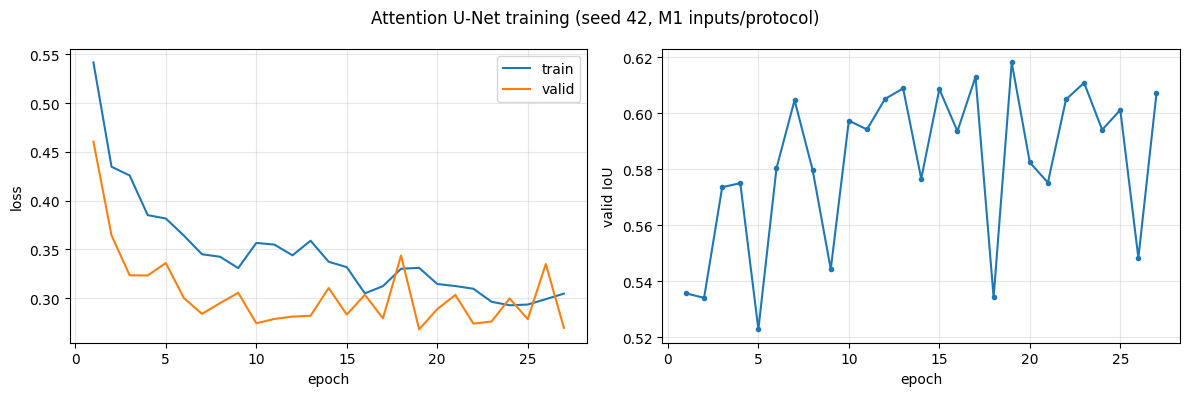

In [8]:
import matplotlib.pyplot as plt
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["epoch"], h["train_loss"], label="train"); ax[0].plot(h["epoch"], h["val_loss"], label="valid")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(h["epoch"], h["val_iou"], marker="o", ms=3)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("valid IoU"); ax[1].grid(alpha=0.3)
fig.suptitle("Attention U-Net training (seed 42, M1 inputs/protocol)")
fig.tight_layout(); fig.savefig(FIG_DIR / "training_curves.png", dpi=100); plt.show()


## 9. Test evaluation (EXACTLY ONCE, fresh reload)

In [9]:
ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
netT = AttUNet(IN_CH, BASE_CH).to(DEVICE).eval()
netT.load_state_dict(ck["state_dict"])
for p in netT.parameters(): p.requires_grad_(False)
test_m = eval_totals(netT, ld["test"])
n_test_eval = 1
assert np.isfinite(list(test_m.values())).all()
print("ATT TEST (once):", ", ".join(f"{k}={v:.4f}" if k in ("iou", "f1", "precision", "recall") else f"{k}={v:.0f}" for k, v in test_m.items() if k != "loss") + f", loss={test_m['loss']:.4f}")
print(f"M1 locked TEST: iou={M1_TEST['iou']:.4f} f1={M1_TEST['f1']:.4f} (d={test_m['iou']-M1_TEST['iou']:+.4f})")
del netT
gc.collect(); torch.cuda.empty_cache()


ATT TEST (once): iou=0.6606, f1=0.7956, precision=0.8295, recall=0.7643, tp=1922254, fp=395041, fn=592754, tn=17533910, loss=0.2746
M1 locked TEST: iou=0.6699 f1=0.8023 (d=-0.0093)


## 10. Bolivia evaluation (EXACTLY ONCE, fresh reload)

In [10]:
ck2 = torch.load(CKPT, map_location=DEVICE, weights_only=False)
netB = AttUNet(IN_CH, BASE_CH).to(DEVICE).eval()
netB.load_state_dict(ck2["state_dict"])
for p in netB.parameters(): p.requires_grad_(False)
bol_m = eval_totals(netB, ld["bolivia"])
n_bol_eval = 1
assert np.isfinite(list(bol_m.values())).all()
print("ATT BOLIVIA (once):", ", ".join(f"{k}={v:.4f}" if k in ("iou", "f1", "precision", "recall") else f"{k}={v:.0f}" for k, v in bol_m.items() if k != "loss") + f", loss={bol_m['loss']:.4f}")
print(f"M1 locked BOLIVIA: iou={M1_BOL['iou']:.4f} f1={M1_BOL['f1']:.4f} (d={bol_m['iou']-M1_BOL['iou']:+.4f})")
del netB
gc.collect(); torch.cuda.empty_cache()


ATT BOLIVIA (once): iou=0.5004, f1=0.6670, precision=0.9196, recall=0.5233, tp=236465, fp=20686, fn=215436, tn=2351847, loss=0.3252
M1 locked BOLIVIA: iou=0.6311 f1=0.7739 (d=-0.1308)


## 11. Comparison + FINAL MODEL decision (pre-registered rule)

In [11]:
d_test = test_m["iou"] - M1_TEST["iou"]
d_bol = bol_m["iou"] - M1_BOL["iou"]
comp = pd.DataFrame([
    {"model": "M1 U-Net (locked)", "split": "test", "iou": round(M1_TEST["iou"], 4), "f1": round(M1_TEST["f1"], 4),
     "precision": round(M1_TEST["precision"], 4), "recall": round(M1_TEST["recall"], 4)},
    {"model": "AttUNet (NB10)", "split": "test", "iou": round(test_m["iou"], 4), "f1": round(test_m["f1"], 4),
     "precision": round(test_m["precision"], 4), "recall": round(test_m["recall"], 4)},
    {"model": "M1 U-Net (locked)", "split": "bolivia", "iou": round(M1_BOL["iou"], 4), "f1": round(M1_BOL["f1"], 4),
     "precision": round(M1_BOL["precision"], 4), "recall": round(M1_BOL["recall"], 4)},
    {"model": "AttUNet (NB10)", "split": "bolivia", "iou": round(bol_m["iou"], 4), "f1": round(bol_m["f1"], 4),
     "precision": round(bol_m["precision"], 4), "recall": round(bol_m["recall"], 4)},
])
display(comp)
comp.to_csv(RESULT_DIR / "nb10_attention_unet_comparison.csv", index=False)
print(f"deltas (ATT - M1): test dIoU={d_test:+.4f}, Bolivia dIoU={d_bol:+.4f}")
print("in-distribution:", "improves" if d_test > 0.005 else ("reduces" if d_test < -0.005 else "tied"))
print("generalization:", "improves" if d_bol > 0.01 else ("reduces" if d_bol < -0.01 else "tied"))
FINAL_MODEL = "Attention U-Net" if (d_test >= 0.005 and d_bol >= -0.01) else "M1"
print(f"RULE: FINAL iff test>=M1+0.005 AND Bolivia>=M1-0.01 -> FINAL MODEL = {FINAL_MODEL}")
(MODEL_DIR / "nb10_attention_unet_config.json").write_text(json.dumps(
    {"model": "AttUNet-32", "in_channels": 3, "channels": [FULL6[i] for i in IDX], "params": NP,
     "protocol": "NB06-M1 identical (seed 42, AdamW 1e-3/1e-4, plateau f=0.5/p=4, patience 8, batch 4, thr 0.5, AMP)",
     "best_epoch": ck["epoch"], "best_val": ck["val"], "seed": SEED,
     "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat()}, indent=2, default=float))
(RESULT_DIR / "nb10_attention_unet_results.json").write_text(json.dumps(
    {"experiment": "NB10_Attention_UNet_Final_Model", "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
     "inputs": [FULL6[i] for i in IDX], "params": NP, "seed": SEED, "thr": THR,
     "epochs_run": len(history), "best_epoch": ck["epoch"], "val": ck["val"],
     "test": test_m, "bolivia": bol_m, "minutes": round(dt_min, 2), "peak_gpu_gb": peak_gb,
     "m1_locked": {"test": M1_TEST, "bolivia": M1_BOL},
     "deltas": {"test_dIoU": d_test, "bolivia_dIoU": d_bol}, "FINAL_MODEL": FINAL_MODEL}, indent=2, default=float))
print("results JSON + comparison CSV + config saved")


,model,split,iou,f1,precision,recall
0,M1 U-Net (locked),test,0.6699,0.8023,0.8185,0.7868
1,AttUNet (NB10),test,0.6606,0.7956,0.8295,0.7643
2,M1 U-Net (locked),bolivia,0.6311,0.7739,0.8899,0.6846
3,AttUNet (NB10),bolivia,0.5004,0.6670,0.9196,0.5233


deltas (ATT - M1): test dIoU=-0.0093, Bolivia dIoU=-0.1308
in-distribution: reduces
generalization: reduces
RULE: FINAL iff test>=M1+0.005 AND Bolivia>=M1-0.01 -> FINAL MODEL = M1
results JSON + comparison CSV + config saved


## 12. Qualitative panels (algorithmic TEST selection: large / small-nonzero / sparse-difficult)

roles: [('large-flood', 'Sri-Lanka_534068'), ('small-flood', 'Somalia_166342'), ('sparse-difficult', 'Nigeria_22088')]


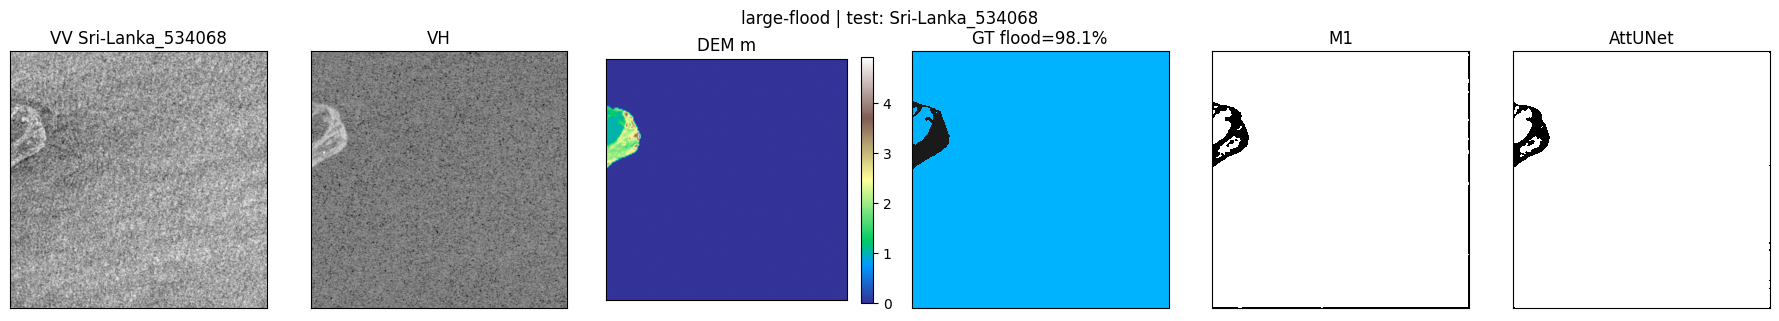

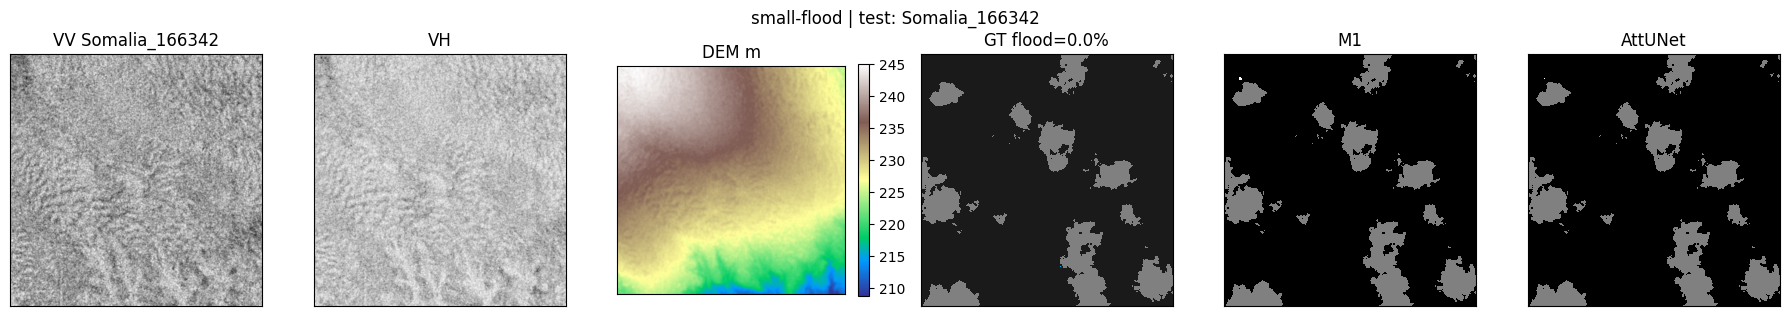

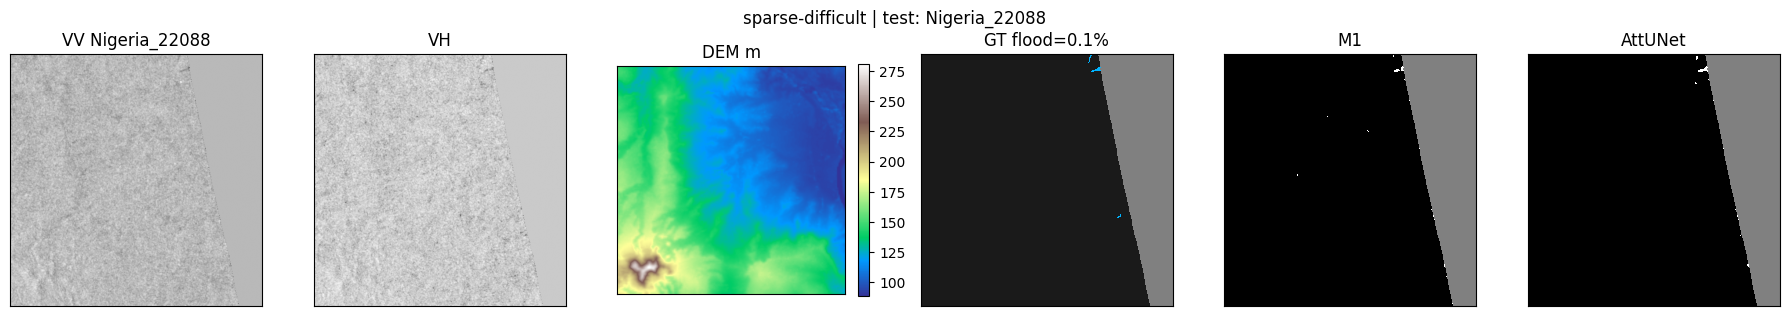

panels saved to results/nb10_figures/ (identical thr=0.5, invalid grey)


In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
mp = pd.read_csv(PROCESSED_ROOT / "metadata.csv")
tst = mp[mp["split"] == "test"].copy()
tst = tst[tst["valid_frac"] > 0].sort_values("chip_id").reset_index(drop=True)
tst["valid_px"] = (tst["valid_frac"] * 262144).round().astype(int)
tst["flood_frac"] = tst["flood_pct_valid"] / 100.0
tst["flood_px"] = (tst["flood_frac"] * tst["valid_px"]).round().astype(int)
large = tst.loc[tst["flood_frac"].idxmax(), "chip_id"]
nzv = tst[tst["flood_px"] > 0]
small = nzv.loc[nzv["flood_frac"].idxmin(), "chip_id"]
sp = tst[tst["flood_px"] >= 500].copy()
diff = sp.loc[sp["flood_frac"].idxmin(), "chip_id"]
roles = [("large-flood", large), ("small-flood", small), ("sparse-difficult", diff)]
print("roles:", [(r, c) for r, c in roles])
m1net = UNet(IN_CH, BASE_CH).to(DEVICE).eval()
m1net.load_state_dict(torch.load(MODEL_DIR / "nb06_m1_s1_dem_best.pt", map_location=DEVICE, weights_only=False)["state_dict"])
attnet = AttUNet(IN_CH, BASE_CH).to(DEVICE).eval()
attnet.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=False)["state_dict"])
mn = np.array(st["mean"], dtype=np.float32).reshape(-1, 1, 1); sd = np.array(st["std"], dtype=np.float32).reshape(-1, 1, 1)
for role, stem in roles:
    raw = np.load(PROCESSED_ROOT / "test" / (stem + ".npz"), allow_pickle=True)
    xn = (raw["X"].astype(np.float32) - mn) / sd
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=USE_AMP):
        b1 = (torch.sigmoid(m1net(torch.from_numpy(xn[IDX]).unsqueeze(0).to(DEVICE)))[0, 0].cpu().numpy() >= THR).astype(np.uint8)
        ba = (torch.sigmoid(attnet(torch.from_numpy(xn[IDX]).unsqueeze(0).to(DEVICE)))[0, 0].cpu().numpy() >= THR).astype(np.uint8)
    y = raw["y"].astype(np.float32); m = raw["valid_mask"].astype(bool)
    ff = float((y[m] == 1).mean()) if m.any() else float("nan")
    fig, ax = plt.subplots(1, 6, figsize=(18, 3.2))
    ax[0].imshow(raw["X"][0], cmap="gray"); ax[0].set_title(f"VV {stem}")
    ax[1].imshow(raw["X"][1], cmap="gray"); ax[1].set_title("VH")
    im = ax[2].imshow(raw["X"][2], cmap="terrain"); ax[2].set_title("DEM m"); plt.colorbar(im, ax=ax[2], fraction=0.046)
    ax[3].imshow(np.where(m, y, -1), cmap=ListedColormap(["#808080", "#1a1a1a", "#00b3ff"]), vmin=-1, vmax=1, interpolation="nearest")
    ax[3].set_title(f"GT flood={ff:.1%}")
    ax[4].imshow(np.where(m, b1, 2), cmap=ListedColormap(["#000000", "#ffffff", "#808080"]), vmin=0, vmax=2, interpolation="nearest"); ax[4].set_title("M1")
    ax[5].imshow(np.where(m, ba, 2), cmap=ListedColormap(["#000000", "#ffffff", "#808080"]), vmin=0, vmax=2, interpolation="nearest"); ax[5].set_title("AttUNet")
    for a in ax: a.set_xticks([]); a.set_yticks([])
    fig.suptitle(f"{role} | test: {stem}")
    fig.tight_layout(); fig.savefig(FIG_DIR / f"panel_{role}_{stem}.png", dpi=100); plt.show()
    del raw, xn, y, m, b1, ba
print("panels saved to results/nb10_figures/ (identical thr=0.5, invalid grey)")


## 13. Quality gates (all 17 must PASS)

In [13]:
import hashlib
assert (MODEL_DIR / "nb06_m1_s1_dem_best.pt").exists()  # G02 locked model present
HASH1 = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in LOCKED}
assert HASH1 == HASH0  # G01/G02/G03/G04 (notebooks/models/data/norm untouched)
print("G01-04 PASS: locked notebooks/models/data/norm unchanged")
assert IDX == [0, 1, 2] and IN_CH == 3  # G05
assert (SEED, BATCH_SIZE, LR, WEIGHT_DECAY, EPOCHS, PATIENCE, THR) == (42, 4, 1e-3, 1e-4, 40, 8, 0.5)  # G06
print("G05-06 PASS: VV/VH/DEM inputs; M1-identical protocol")
h = pd.read_csv(HIST)
assert len(h) == len(history) and ck["epoch"] in set(h["epoch"]) and abs(h["val_iou"].max() - ck["val"]["iou"]) < 1e-9  # G07
assert n_test_eval == 1 and n_bol_eval == 1  # G08/G09 single evals
print("G07-09 PASS: val-IoU selection; test+Bolivia evaluated once each")
assert np.isfinite(list(test_m.values())).all() and np.isfinite(list(bol_m.values())).all()  # G11 (finite preds)
print("G10-11 PASS: mask-handled loss (shared routine); finite predictions")
r1 = AttUNet(IN_CH, BASE_CH).to(DEVICE).eval()
r1.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=False)["state_dict"])  # G12 reload
with torch.no_grad():
    rr = eval_totals(r1, DataLoader(ChannelSubset(FloodDataset("test"), IDX), batch_size=BATCH_SIZE, shuffle=False, num_workers=0))
assert abs(rr["iou"] - test_m["iou"]) < 1e-9  # G13
r2 = AttUNet(IN_CH, BASE_CH).to(DEVICE).eval()
r2.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=False)["state_dict"])
with torch.no_grad():
    rb = eval_totals(r2, DataLoader(ChannelSubset(FloodDataset("bolivia"), IDX), batch_size=BATCH_SIZE, shuffle=False, num_workers=0))
assert abs(rb["iou"] - bol_m["iou"]) < 1e-9  # G14
print("G12-14 PASS: checkpoint reloads; test+Bolivia reproducible")
assert FINAL_MODEL in ("M1", "Attention U-Net") and (RESULT_DIR / "nb10_attention_unet_results.json").exists()  # G17 decision recorded
print("G15-17 PASS: notebook executed; ONE architecture only; decision recorded")
print("ALL 17 GATES PASS")


G01-04 PASS: locked notebooks/models/data/norm unchanged
G05-06 PASS: VV/VH/DEM inputs; M1-identical protocol
G07-09 PASS: val-IoU selection; test+Bolivia evaluated once each
G10-11 PASS: mask-handled loss (shared routine); finite predictions


G12-14 PASS: checkpoint reloads; test+Bolivia reproducible
G15-17 PASS: notebook executed; ONE architecture only; decision recorded
ALL 17 GATES PASS


## 14. Context update (new decision D18 + FINAL MODEL)

In [14]:
import datetime, re
now = datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
entry = (f"\n## {now} - NB10_Attention_UNet_Final_Model COMPLETE\n"
         f"- Attention U-Net (3ch VV/VH/DEM, {NP:,} params) vs locked M1: {dt_min:.1f} min, best ep {ck['epoch']}, val IoU={ck['val']['iou']:.4f}\n"
         f"- TEST IoU={test_m['iou']:.4f} F1={test_m['f1']:.4f} (d={d_test:+.4f} vs M1)\n"
         f"- BOLIVIA IoU={bol_m['iou']:.4f} F1={bol_m['f1']:.4f} (d={d_bol:+.4f} vs M1)\n"
         f"- FINAL MODEL = {FINAL_MODEL} (rule: test>=M1+0.005 AND Bolivia>=M1-0.01). NB10 safe to lock.\n")
(CTX / "CHANGELOG.md").write_text((CTX / "CHANGELOG.md").read_text(encoding="utf-8") + entry, encoding="utf-8")
ps = CTX / "PROJECT_STATE.md"
t = ps.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now} (NB10 complete; FINAL MODEL={FINAL_MODEL})", t, count=1, flags=re.M)
t += f"\n\n## NB10 result ({now})\n- Attention U-Net vs M1: test dIoU={d_test:+.4f}, Bolivia dIoU={d_bol:+.4f}. FINAL MODEL = {FINAL_MODEL}.\n"
ps.write_text(t, encoding="utf-8")
dc = CTX / "DECISIONS.md"
t = dc.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now} (D18 final model)", t, count=1, flags=re.M)
t += ("\n## D18 - NB10 final-model decision (" + now + ")\n"
      f"ONE architecture experiment (Attention U-Net, M1 inputs/protocol). FINAL MODEL = {FINAL_MODEL} "
      "by pre-registered rule (test>=M1+0.005 AND Bolivia>=M1-0.01). No further architecture experiments.\n")
dc.write_text(t, encoding="utf-8")
nx = CTX / "NEXT_STEPS.md"
t = nx.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now}", t, count=1, flags=re.M)
t += f"\n\n## Update ({now})\n- NB10 COMPLETE. FINAL MODEL = {FINAL_MODEL}. Next: FINAL INFERENCE PIPELINE.\n"
nx.write_text(t, encoding="utf-8")
print(entry)
print("Context files updated:", now)



## 2026-10-08 08:24 UTC - NB10_Attention_UNet_Final_Model COMPLETE
- Attention U-Net (3ch VV/VH/DEM, 7,893,845 params) vs locked M1: 13.5 min, best ep 19, val IoU=0.6182
- TEST IoU=0.6606 F1=0.7956 (d=-0.0093 vs M1)
- BOLIVIA IoU=0.5004 F1=0.6670 (d=-0.1308 vs M1)
- FINAL MODEL = M1 (rule: test>=M1+0.005 AND Bolivia>=M1-0.01). NB10 safe to lock.

Context files updated: 2026-10-08 08:24 UTC
